### 1. Understanding GAN

##### A Generative Adversarial Network (GAN) consists of two models:
- Generator (G) → creates fake images
- Discriminator (D) → detects real vs fake
##### They compete:
- Generator tries to fool discriminator
- Discriminator tries to catch generator
This adversarial process improves both models over time.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

#### Load & Preprocess Dataset

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train - 127.5) / 127.5

# Reshape
x_train = np.expand_dims(x_train, axis=-1)

print(x_train.shape)

(60000, 28, 28, 1)


#### 2. Generator Model

In [3]:
from tensorflow.keras import Input

def build_generator():
    model = tf.keras.Sequential([
        Input(shape=(100,)), 

        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same',
                               use_bias=False, activation='tanh')
    ])
    return model

generator = build_generator()

#### 3. Discriminator Model

In [4]:
def build_discriminator():
    model = tf.keras.Sequential([
        Input(shape=(28,28,1)),

        layers.Conv2D(64, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = build_discriminator()

#### 4. Loss & Optimizer

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

#### 5. Training Loop

In [6]:
EPOCHS = 20
BATCH_SIZE = 256
noise_dim = 100

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)\
                .shuffle(60000).batch(BATCH_SIZE)

gen_losses = []
disc_losses = []

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

#### 6. Generate Images Function

In [7]:
def generate_images(model, epoch):
    noise = tf.random.normal([16, noise_dim])
    predictions = model(noise, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

#### 7. Training Execution

Epoch 1: G Loss=0.8029398918151855, D Loss=1.3551414012908936
Epoch 2: G Loss=0.6955960988998413, D Loss=1.2948923110961914
Epoch 3: G Loss=0.7490501403808594, D Loss=1.2459681034088135
Epoch 4: G Loss=0.7840685248374939, D Loss=1.3903462886810303
Epoch 5: G Loss=0.9944291114807129, D Loss=1.1510608196258545


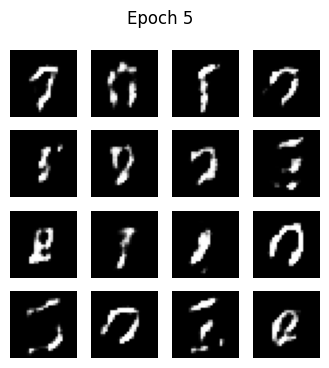

Epoch 6: G Loss=0.5953325629234314, D Loss=1.2558743953704834
Epoch 7: G Loss=0.7357815504074097, D Loss=1.264326810836792
Epoch 8: G Loss=0.7674733400344849, D Loss=1.3754310607910156
Epoch 9: G Loss=0.866547703742981, D Loss=1.2841325998306274
Epoch 10: G Loss=0.7637426853179932, D Loss=1.3402559757232666


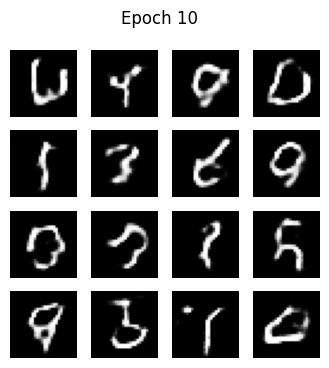

Epoch 11: G Loss=0.7773382067680359, D Loss=1.4674263000488281
Epoch 12: G Loss=0.7952589988708496, D Loss=1.2487571239471436
Epoch 13: G Loss=0.8399598598480225, D Loss=1.3457467555999756
Epoch 14: G Loss=0.7823868989944458, D Loss=1.3091046810150146
Epoch 15: G Loss=0.8309897780418396, D Loss=1.5136182308197021


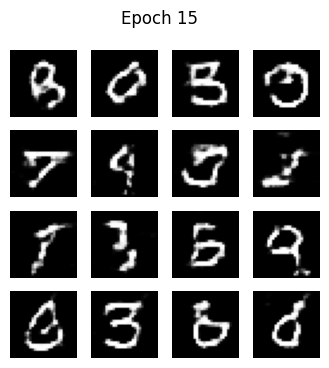

Epoch 16: G Loss=0.8336056470870972, D Loss=1.3653223514556885
Epoch 17: G Loss=0.7174436450004578, D Loss=1.297577142715454
Epoch 18: G Loss=0.6649289131164551, D Loss=1.3786976337432861
Epoch 19: G Loss=0.895172119140625, D Loss=1.3106193542480469
Epoch 20: G Loss=0.6489596366882324, D Loss=1.4367492198944092


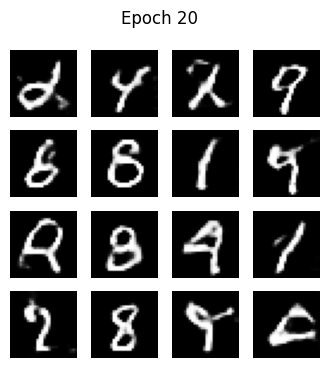

In [8]:
for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)

    gen_losses.append(g_loss)
    disc_losses.append(d_loss)

    print(f"Epoch {epoch+1}: G Loss={g_loss}, D Loss={d_loss}")

    if (epoch+1) % 5 == 0:
        generate_images(generator, epoch+1)

#### 8. Loss Curve

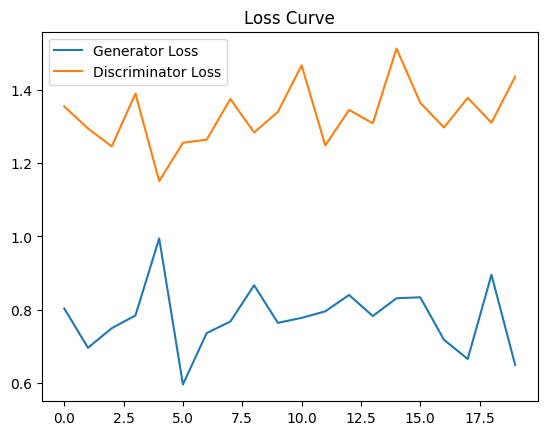

In [9]:
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

The generator and discriminator losses fluctuate throughout the training process, which is expected in GAN models due to their adversarial nature. Unlike traditional models, GANs do not converge to a single minimum. Instead, both networks continuously improve in response to each other.

The generator loss remains in the range of approximately 0.6 to 1.0, indicating that it is learning to generate increasingly realistic images. The discriminator loss stays around 1.2 to 1.5, suggesting that it maintains a balance between correctly identifying real and fake images.

Overall, the training process demonstrates a stable adversarial balance between the generator and discriminator.